In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from base_class import base_class
from get_radial_profiles import Profiles
from get_Pkzs import get_Pkz
from get_Cls import get_Cl
from get_Xis import get_xi
from get_covs import get_cov
import gaussian_tension







/tmp/ipykernel_3459755/854669679.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


np.float64(3.4810784346271073)

In [1]:
sys.path.append('/projects/bdne/spandey3/cartosky')
import cartosky
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



/projects/bdne/spandey3/cartosky/cartosky/crs.py:11: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(cartopy.__version__) >= LooseVersion('0.20.0'):
/projects/bdne/spandey3/cartosky/cartosky/crs.py:11: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if LooseVersion(cartopy.__version__) >= LooseVersion('0.20.0'):


In [2]:
import healpy as hp
ymap = hp.read_map('/work/hdd/bdne/spandey3/ilc_SZ_deproj_cib_beta_1p6_cibdBeta_yy_noKspaceCor_healpix_ns4096.fits')
mask = hp.read_map('/work/hdd/bdne/spandey3/mask_updated_ACTDR6xDESY3.fits')


In [3]:
import matplotlib.pyplot as plt
%matplotlib inline


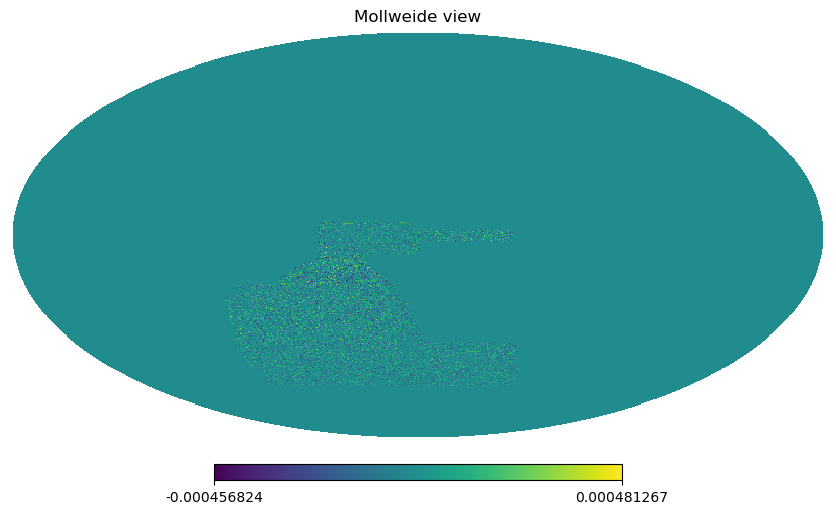

In [4]:
hp.mollview(ymap*mask)


In [12]:
nside = 512
ymap_ud = hp.ud_grade(ymap, nside)
mask_ud = hp.ud_grade(mask, nside)



In [5]:
import numpy as np
import matplotlib.pyplot as plt
plt.rc('text', usetex=True)
%matplotlib inline



In [ ]:
# fig = plt.figure(figsize=(8, 12))
# # fig.set_size_inches(8, 12)
# m = cartosky.Skymap(projection='mbtfpq', celestial=True, gridlines=True)
# llcrnrlon,urcrnrlon = -55, 100
# llcrnrlat,urcrnrlat = -70, 10
# m.ax.set_extent([llcrnrlon,urcrnrlon,llcrnrlat,urcrnrlat])
# # m.ax.s
# pxnums = np.where((mask_ud>0))[0]
# pxvals = ymap_ud[pxnums]
# #m.draw_hpxmap(pxvals, pixel=pxnums, nside=2048)
# # pxnums = np.concatenate([pxnums, np.where((mask_des>0) & (mask_y>0))[0]])
# # pxvals = np.concatenate([pxvals, ymap_spt[np.where((mask_des>0) & (mask_y>0))[0]]])
# # im, _, _, _ = m.draw_hpxmap(pxvals, pixel=pxnums, nside=4096, smooth=0.25, xsize=1500)
# im, _, _, _ = m.draw_hpxmap(pxvals, pixel=pxnums, nside=nside, smooth=0.25, xsize=1000)
# m.ax.annotate('RA [deg]', (0.45, -0.12), xycoords='axes fraction', 
#             fontsize=18)
# m.ax.annotate('Dec [deg]', (-0.12, 0.5), xycoords='axes fraction', rotation=90, 
#             fontsize=18)
# m.ax.invert_xaxis()

# # m.ax.set_
# m.ax.xaxis.set_tick_params(labelsize=14)
# m.ax.xaxis.set_tick_params(labelsize=14)

# cbaxes = inset_axes(m.ax, width="25%", height="3%", loc='upper left') 
# # plt.colorbar(im, cax=cbaxes, orientation='horizontal', label='$y$')
# cb = plt.colorbar(im, cax=cbaxes, orientation='horizontal').set_label('$y$', fontsize=16)
# # fig.set_size_inches(8, 12)
# # fig.tight_layout()

# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# # plt.savefig(sdir + 'ACT_ymap_DESarea.pdf', bbox_inches='tight', dpi=300)

# # fig.savefig('../figures/map_y.pdf')


/u/spandey3/myjax/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:394: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/projects/bdne/spandey3/cartosky/cartosky/healpix.py:223: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  smooth = hp.smoothing(hpxmap, sigma=np.radians(sigma), verbose=False)


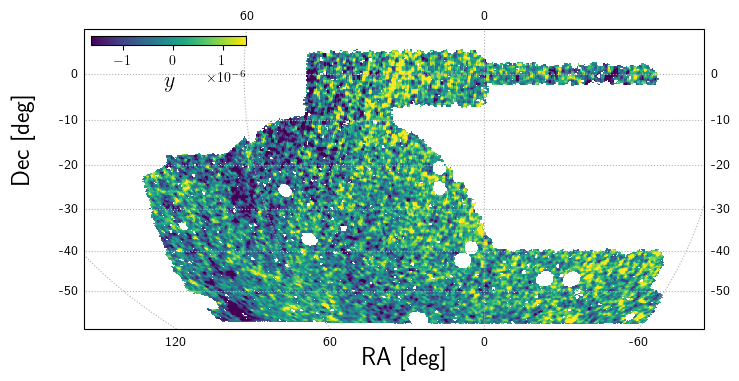

In [58]:
# fig = plt.figure(figsize=(8, 12))
plt.figure()
# plt.gcf().set_size_inches(8, 12)
# fig.set_size_inches(8, 12)
m = cartosky.Skymap(projection='mbtfpq', celestial=True, gridlines=True)
fig = m.ax.figure
# fig.set_size_inches(8, 6)
m.ax.figure.set_size_inches(8, 6)
llcrnrlon,urcrnrlon = -55, 100
llcrnrlat,urcrnrlat = -60, 10
m.ax.set_extent([llcrnrlon,urcrnrlon,llcrnrlat,urcrnrlat])
m.ax.set_aspect = 0.3
# m.ax.s
pxnums = np.where((mask_ud>0))[0]
pxvals = ymap_ud[pxnums]
#m.draw_hpxmap(pxvals, pixel=pxnums, nside=2048)
# pxnums = np.concatenate([pxnums, np.where((mask_des>0) & (mask_y>0))[0]])
# pxvals = np.concatenate([pxvals, ymap_spt[np.where((mask_des>0) & (mask_y>0))[0]]])
# im, _, _, _ = m.draw_hpxmap(pxvals, pixel=pxnums, nside=4096, smooth=0.25, xsize=1500)
im, _, _, _ = m.draw_hpxmap(pxvals, pixel=pxnums, nside=nside, smooth=0.25, xsize=1000)
m.ax.annotate('RA [deg]', (0.45, -0.12), xycoords='axes fraction', 
            fontsize=18)
m.ax.annotate('Dec [deg]', (-0.12, 0.5), xycoords='axes fraction', rotation=90, 
            fontsize=18)
m.ax.invert_xaxis()

# m.ax.set_
m.ax.xaxis.set_tick_params(labelsize=14)
m.ax.xaxis.set_tick_params(labelsize=14)

cbaxes = inset_axes(m.ax, width="25%", height="3%", loc='upper left') 
# plt.colorbar(im, cax=cbaxes, orientation='horizontal', label='$y$')
cb = plt.colorbar(im, cax=cbaxes, orientation='horizontal').set_label('$y$', fontsize=16)
# fig.set_size_inches(8, 12)
# fig.tight_layout()

sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'ACT_ymap_DESarea.pdf', bbox_inches='tight', dpi=300)

# fig.savefig('../figures/map_y.pdf')


In [52]:
m.ax.figure.__dict__


{'_stale': True,
 'stale_callback': None,
 'figure': <Figure size 1200x300 with 2 Axes>,
 '_transform': None,
 '_transformSet': False,
 '_visible': True,
 '_animated': False,
 '_alpha': None,
 'clipbox': None,
 '_clippath': None,
 '_clipon': True,
 '_label': '',
 '_picker': None,
 '_rasterized': False,
 '_agg_filter': None,
 '_mouseover': False,
 '_callbacks': <matplotlib.cbook.CallbackRegistry at 0xfffe6731d510>,
 '_remove_method': None,
 '_url': None,
 '_gid': None,
 '_snap': None,
 '_sketch': None,
 '_path_effects': [],
 '_sticky_edges': _XYPair(x=[], y=[]),
 '_in_layout': True,
 '_suptitle': None,
 '_supxlabel': None,
 '_supylabel': None,
 '_align_label_groups': {'x': <matplotlib.cbook.Grouper at 0xfffe6731d540>,
  'y': <matplotlib.cbook.Grouper at 0xfffe6731fd00>,
  'title': <matplotlib.cbook.Grouper at 0xfffe6731fbe0>},
 '_localaxes': [<SkyAxes: >, <AxesHostAxes: xlabel='$y$'>],
 'artists': [],
 'lines': [],
 'patches': [],
 'texts': [],
 'images': [],
 'legends': [],
 'subfigs':

In [53]:
m.ax.set_aspect = 0.8


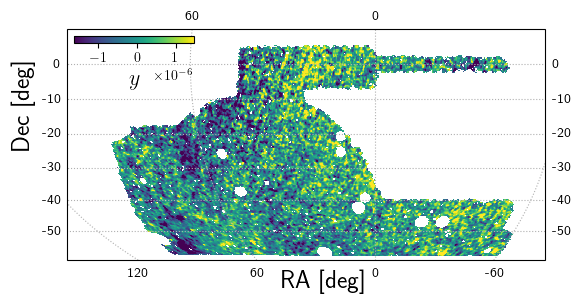

In [54]:
fig

In [ ]:
# m.__dict__
m.ax.


{'projection': <Projected CRS: +proj=mbtfpq +a=6378137.0 +b=6378137.0 +lon_0=0 +l ...>
 Name: mbtfpq
 Axis Info [cartesian]:
 - E[east]: Easting (metre)
 - N[north]: Northing (metre)
 Area of Use:
 - undefined
 Coordinate Operation:
 - name: unknown
 - method: Flat Polar Quartic
 Datum: unknown
 - Ellipsoid: unknown
 - Prime Meridian: Greenwich,
 '_stale': True,
 'stale_callback': <function matplotlib.figure._stale_figure_callback(self, val)>,
 '_axes': <SkyAxes: >,
 'figure': <Figure size 1200x300 with 2 Axes>,
 '_transform': None,
 '_transformSet': False,
 '_visible': True,
 '_animated': False,
 '_alpha': None,
 'clipbox': None,
 '_clippath': None,
 '_clipon': True,
 '_label': '',
 '_picker': None,
 '_rasterized': False,
 '_agg_filter': None,
 '_mouseover': False,
 '_callbacks': <matplotlib.cbook.CallbackRegistry at 0xfffe6731fd90>,
 '_remove_method': <bound method FigureBase.delaxes of <Figure size 1200x300 with 2 Axes>>,
 '_url': None,
 '_gid': None,
 '_snap': None,
 '_sketch': Non

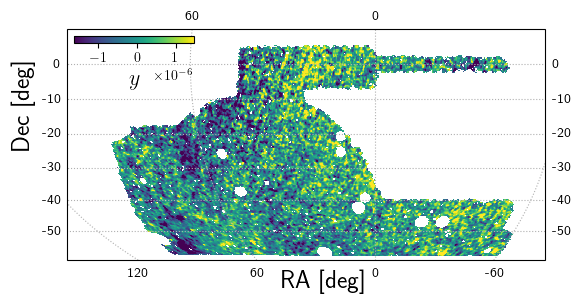

<Figure size 640x480 with 0 Axes>

In [49]:
# m
# plt.show()
# m.aspect
# fig.resize
fig.set_size_inches(12, 3, forward=True)
# fig
plt.draw()
fig


In [2]:
# ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/'
# # df = pk.load(open(ldir + 'mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))

# # df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))

ldir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Feb/'
# df = pk.load(open(ldir + 'mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))

# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v9_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_4500_warmup_3500_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
# df = pk.load(open('/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/chains_Jan/mcmc_v10_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_7000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))
df = pk.load(open(ldir + 'mcmc_v10_widemuej_nzfix_probe_all_modelmatter_DMB_deproj_cib_1p7_dBeta_samples_8000_warmup_8000_num_chains_64_treedepth_4_gtysc_True_Y3xipmsc_False.pkl','rb'))




In [3]:
samps = []
keys = []
for key in df:
    # if ('base' not in key) and ('decentered' not in key):
        # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging']:
        if key not in ['RUN_SETTINGS', 'diverging']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            else:
                samps.append(df[key])
                keys.append(key)            

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')


ind_post = keys.index('potential_energy')
post = -1.* samps[:,ind_post]

map_ind = np.where(post == post.max())[0][0]

saved_bestfit = {}
for jk, key in enumerate(keys):
    print(key, samps[map_ind, jk])
    saved_bestfit[key] = samps[map_ind, jk]



(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
(512000,)
A_IA 0.14377885207895114
A_IA_base 0.14377885207895114
Delta_z_bias_array_0 0.007653930225780798
Delta_z_bias_array_1 -0.012598270941276137
Delta_z_bias_array_2 -0.012841804698650358
Delta_z_bias_array_3 0.013288081442525992
Delta_z_bias_array_decentered_0 0.42521834587671103
Delta_z_bias_array_decentered_1 -0.8398847294184092
Delta_z_bias_array_decentered_2 -1.1674367907863963
Delta_z_bias_array_decentered_3 0.7816518495603524
Ob0 0.04302213809734518
Ob0_base -1.0466792853982227
Om0 0.2541951448373219
Om0_base -0.6870728274401721
alpha_ky 1.049289760822429
alpha_ky_base 0.7393464123364355
alpha_nt 0.22447369527641473
alpha_nt_base -0.3063156566830232
eta_IA 1.002030465527282
eta_IA_base 1.002030465527282
h 0.7046634431189261
h_base 0.06995164678389365
mu_beta 0.2209875338571503
mu_beta_base -2.1160498645713988
mult_shear_bias_a

In [4]:
# potential_energy -4916.635080802822
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
new_data = read_yaml(abs_path_params + '/DESxACT/params_v2.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)


# saved_bestift
from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 4
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-4)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])


analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]

lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)


for key in saved_bestfit.keys():
    if key in list(sim_params_dict.keys()):
        sim_params_dict[key] = float(saved_bestfit[key])
    if key in list(sim_params_dict['cosmo'].keys()):
        sim_params_dict['cosmo'][key] = float(saved_bestfit[key])
        if key == 'h':
            sim_params_dict['cosmo']['H0'] = 100*saved_bestfit[key]
    if key in list(other_params_dict.keys()):
        other_params_dict[key] = float(saved_bestfit[key])
for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
    other_params_dict['Delta_z_bias_array'][jb] = saved_bestfit[f'Delta_z_bias_array_{jb}']
for jb in range(analysis_dict['nz_source_info_dict']['nbins']):
    other_params_dict['mult_shear_bias_array'][jb] = saved_bestfit[f'mult_shear_bias_array_{jb}']




In [5]:
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)



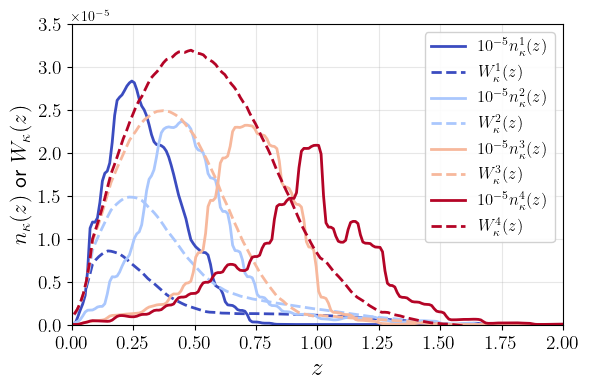

In [27]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Create a colormap from blue to red for jb values
colors = plt.cm.coolwarm(np.linspace(0, 1, 4))  # 4 colors from blue to red

plt.figure(figsize=(6, 4))  # Larger figure size

for jb in range(4):
    # Same color for both curves with the same jb value
    color = colors[jb]
    
    # Plot with better line styles and thicknesses
    plt.plot(Cls_test.z_array_nz, 1e-5*Cls_test.pzs_inp_mat[jb,:], 
             ls='-', lw=2, color=color, 
             label=f'$10^{{-5}} n^{{{jb+1}}}_{{\\kappa}}(z)$')
    
    plt.plot(Cls_test.z_array_for_Cls, Cls_test.Wk_mat[jb,:], 
             ls='--', lw=2, color=color, 
             label=f'$W^{{{jb+1}}}_{{\\kappa}}(z)$')

# Improve the plot appearance
plt.legend(frameon=True, framealpha=0.9, fontsize=12)
plt.xlabel(r'$z$', fontsize=18)
plt.ylabel(r'$n_{\kappa}(z)$ or $W_{\kappa}(z)$', fontsize=16)
plt.xlim(0.0, 2.0)
plt.ylim(0.0, 3.5e-5)
plt.grid(True, alpha=0.3)
#set the tick label sizes:
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
plt.savefig(save_plot_dir + 'Wk_nz.pdf', bbox_inches='tight')



(0.0, 2.0)

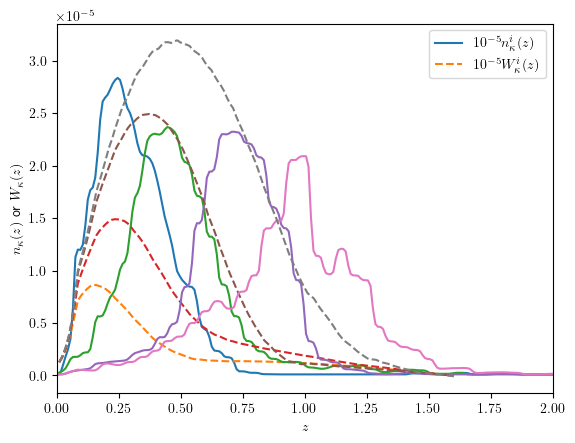

In [17]:
pl.figure()
for jb in range(4):
    if jb == 0:
        pl.plot(Cls_test.z_array_nz, 1e-5*Cls_test.pzs_inp_mat[jb,:], ls='-', label=r'$10^{-5} n^{i}_{\kappa}(z)$')
        pl.plot(Cls_test.z_array_for_Cls, Cls_test.Wk_mat[jb,:], ls='--', label=r'$W^{i}_{\kappa}(z)$')
    else:
        pl.plot(Cls_test.z_array_nz, 1e-5*Cls_test.pzs_inp_mat[jb,:], ls='-')
        pl.plot(Cls_test.z_array_for_Cls, Cls_test.Wk_mat[jb,:], ls='--')
pl.legend()
pl.xlabel(r'$z$')
pl.ylabel(r'$n_{\kappa}(z)$ or $W_{\kappa}(z)$')
pl.xlim(0.0, 2.0)

